In [1]:
import pandas as pd
import config, os
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = os.path.join(config.DATA_DIR, 'archive', 'FaceForensics++_C23')
CSV_PATH = os.path.join(DATA_PATH, 'csv')
TRAIN_PATH = os.path.join(DATA_PATH, 'training_set')
VAL_PATH = os.path.join(DATA_PATH, 'valdiation_set')

In [3]:
train_df = pd.read_csv(os.path.join(CSV_PATH, 'TRAIN.csv'))
test_df = pd.read_csv(os.path.join(CSV_PATH, 'TEST.csv'))

### 데이터 불균형 해소 후 저장

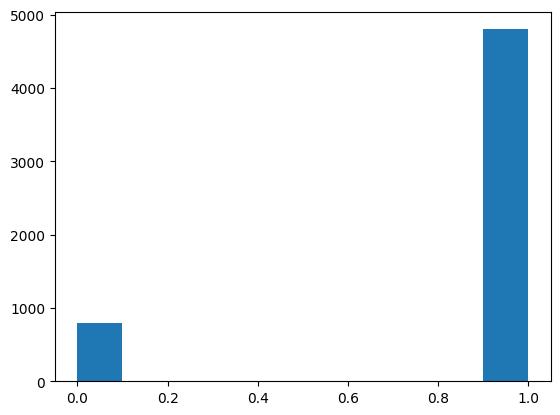

In [4]:
plt.hist(x=train_df.Label_int)
plt.show()

-> original << deepfake

In [5]:
train_df

,File Path,data,crops_path,Label_int
0,NeuralTextures/149_152.mp4,NeuralTextures,data\archive\FaceForensics++_C23\crops\NeuralT...,1
1,FaceSwap/548_632.mp4,FaceSwap,data\archive\FaceForensics++_C23\crops\FaceSwa...,1
2,original/569.mp4,original,data\archive\FaceForensics++_C23\crops\origina...,0
3,NeuralTextures/608_675.mp4,NeuralTextures,data\archive\FaceForensics++_C23\crops\NeuralT...,1
4,original/449.mp4,original,data\archive\FaceForensics++_C23\crops\origina...,0
...,...,...,...,...
5595,FaceSwap/581_697.mp4,FaceSwap,data\archive\FaceForensics++_C23\crops\FaceSwa...,1
5596,Deepfakes/189_200.mp4,Deepfakes,data\archive\FaceForensics++_C23\crops\Deepfak...,1
5597,FaceSwap/508_831.mp4,FaceSwap,data\archive\FaceForensics++_C23\crops\FaceSwa...,1
5598,FaceSwap/971_564.mp4,FaceSwap,data\archive\FaceForensics++_C23\crops\FaceSwa...,1


In [6]:
train_df_real = train_df[train_df['Label_int'] == 0]
train_df_fake = train_df[train_df['Label_int'] == 1]
train_df_fake_down = train_df_fake.sample(n=len(train_df_real), random_state=42)
train_df_balanced = pd.concat([train_df_real, train_df_fake_down]).sample(frac=1, random_state=42).reset_index(drop=True)

In [7]:
train_df_balanced.to_csv(os.path.join(CSV_PATH, 'BALANCED_TRAIN.csv'), index=False)

In [8]:
train_df_balanced.crops_path[0]

'data\\archive\\FaceForensics++_C23\\crops\\original\\466'